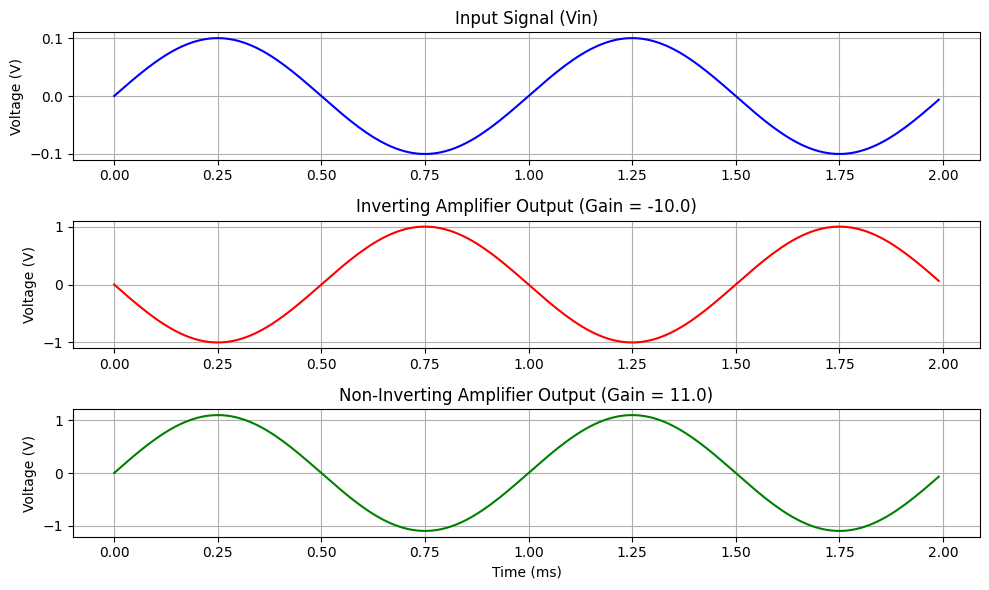

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 회로 파라미터
Rf = 10e3   # 피드백 저항 (10kΩ)
Rin = 1e3   # 입력 저항 (1kΩ)
gain_inverting = -Rf / Rin
gain_non_inverting = 1 + (Rf / Rin)

# 시간축 및 입력 신호
fs = 100e3   # 샘플링 주파수
f = 1e3      # 입력 사인파 주파수
t = np.arange(0, 2e-3, 1/fs)  # 2ms 구간
Vin = 0.1 * np.sin(2 * np.pi * f * t)  # 0.1V 진폭

# 출력 신호
Vout_inv = gain_inverting * Vin
Vout_noninv = gain_non_inverting * Vin

# 시각화
plt.figure(figsize=(10, 6))

# 입력 신호
plt.subplot(3, 1, 1)
plt.plot(t * 1000, Vin, label='Input (Vin)', color='blue')
plt.title('Input Signal (Vin)')
plt.ylabel('Voltage (V)')
plt.grid(True)

# 반전 증폭기 출력
plt.subplot(3, 1, 2)
plt.plot(t * 1000, Vout_inv, label='Inverting Output', color='red')
plt.title(f'Inverting Amplifier Output (Gain = {gain_inverting:.1f})')
plt.ylabel('Voltage (V)')
plt.grid(True)

# 비반전 증폭기 출력
plt.subplot(3, 1, 3)
plt.plot(t * 1000, Vout_noninv, label='Non-Inverting Output', color='green')
plt.title(f'Non-Inverting Amplifier Output (Gain = {gain_non_inverting:.1f})')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.grid(True)

plt.tight_layout()
plt.show()


In [1]:
import numpy as np

# =========================================================================
# 1. 가상 데이터 생성 (전기공학적 시나리오)
# =========================================================================
# 센서 입력 전압 (V_in)
X_data = np.array([0.5, 1.0, 1.5, 2.0, 2.5])

# [시나리오 A] 비반전 회로 목표: 입력 전압을 정확히 3배 증폭해야 함
Y_target_non_inv = np.array([1.5, 3.0, 4.5, 6.0, 7.5])

# [시나리오 B] 반전 회로 목표: 입력이 커질수록 출력이 낮아지는 음의 관계를 가짐
Y_target_inv = np.array([4.0, 3.0, 2.0, 1.0, 0.0])


# =========================================================================
# 2. 머신러닝 기반 OP Amp 회로 학습 클래스
# =========================================================================
class OpaCircuitLearner:
    def __init__(self, R1=10000.0):
        self.R1 = R1  # 고정 저항 R1 = 10k ohm
        
        # 학습할 파라미터 초기화 (임의의 초기값 설정)
        self.Rf = 5000.0      # 피드백 저항 초기값: 5k ohm
        self.Vref = 0.0       # 기준 오프셋 전압 초기값: 0V
        
    def train_non_inverting(self, X, Y_target, epochs=2000, lr=1e-10):
        """ 비반전 증폭기 학습: W = 1 + Rf/R1 """
        print("\n--- [학습 시작] 비반전 증폭기 모델 ---")
        
        for epoch in range(epochs):
            # 1) 현재 저항 값에 따른 가중치(W) 계산 및 회로 예측 출력
            W = 1 + (self.Rf / self.R1)
            Y_pred = W * X
            
            # 2) 손실 함수 계산 (Mean Squared Error)
            loss = np.mean((Y_pred - Y_target) ** 2)
            
            # 3) 미분을 통한 경사(Gradient) 계산 (체인 룰 적용)
            # dLoss/dRf = dLoss/dY_pred * dY_pred/dW * dW/dRf
            dLoss_dYpred = 2 * (Y_pred - Y_target) / len(X)
            dYpred_dW = X
            dW_dRf = 1 / self.R1
            
            dRf = np.sum(dLoss_dYpred * dYpred_dW * dW_dRf)
            
            # 4) 경사하강법으로 파라미터 업데이트
            self.Rf -= lr * dRf
            
            if (epoch + 1) % 400 == 0:
                print(f"Epoch {epoch+1:4d} | Loss: {loss:.6f} | 계산된 Rf: {self.Rf/1000:.2f} kΩ")
                
        final_gain = 1 + (self.Rf / self.R1)
        print(f"▶ 학습 완료! 최종 설계된 비반전 회로 저항 Rf = {self.Rf/1000:.2f} kΩ (전압 이득: {final_gain:.2f}배)")

    def train_inverting(self, X, Y_target, epochs=5000, lr_rf=1e-9, lr_v=1e-3):
        """ 오프셋이 있는 반전 증폭기 학습: W = -Rf/R1, B = (1 + Rf/R1)*Vref """
        print("\n--- [학습 시작] 오프셋 반전 증폭기 모델 ---")
        
        for epoch in range(epochs):
            # 1) 회로 수식 기반 예측
            W = -(self.Rf / self.R1)
            B = (1 + (self.Rf / self.R1)) * self.Vref
            Y_pred = W * X + B
            
            # 2) 손실 계산
            loss = np.mean((Y_pred - Y_target) ** 2)
            
            # 3) 편미분(Gradient) 계산
            dLoss_dYpred = 2 * (Y_pred - Y_target) / len(X)
            
            # Rf에 대한 미분
            dYpred_dRf = (-1/self.R1) * X + (1/self.R1) * self.Vref
            dRf = np.sum(dLoss_dYpred * dYpred_dRf)
            
            # Vref에 대한 미분
            dYpred_dVref = 1 + (self.Rf / self.R1)
            dVref = np.sum(dLoss_dYpred * dYpred_dVref)
            
            # 4) 업데이트
            self.Rf -= lr_rf * dRf
            self.Vref -= lr_v * dVref
            
            if (epoch + 1) % 1000 == 0:
                print(f"Epoch {epoch+1:4d} | Loss: {loss:.6f} | Rf: {self.Rf/1000:.2f} kΩ | Vref: {self.Vref:.2f} V")
                
        print(f"▶ 학습 완료! 최종 설계된 반전 회로: Rf = {self.Rf/1000:.2f} kΩ, Vref = {self.Vref:.2f} V")
        print(f"   (이득: {-(self.Rf/self.R1):.2f}배, 편향 시프트값: {(1 + (self.Rf/self.R1))*self.Vref:.2f}V)")


# =========================================================================
# 3. 프로그램 실행 및 결과 검증
# =========================================================================
if __name__ == "__main__":
    # 고정 저항 R1 = 10kΩ 규격으로 인스턴스 생성
    learner = OpaCircuitLearner(R1=10000.0)
    
    # 1) 비반전 회로 파라미터 학습 기동
    learner.train_non_inverting(X_data, Y_target_non_inv)
    
    # 2) 파라미터 초기화 후 반전 회로 학습 기동
    learner.Rf = 5000.0
    learner.train_inverting(X_data, Y_target_inv)


--- [학습 시작] 비반전 증폭기 모델 ---
Epoch  400 | Loss: 6.187500 | 계산된 Rf: 5.00 kΩ
Epoch  800 | Loss: 6.187500 | 계산된 Rf: 5.00 kΩ
Epoch 1200 | Loss: 6.187500 | 계산된 Rf: 5.00 kΩ
Epoch 1600 | Loss: 6.187500 | 계산된 Rf: 5.00 kΩ
Epoch 2000 | Loss: 6.187500 | 계산된 Rf: 5.00 kΩ
▶ 학습 완료! 최종 설계된 비반전 회로 저항 Rf = 5.00 kΩ (전압 이득: 1.50배)

--- [학습 시작] 오프셋 반전 증폭기 모델 ---
Epoch 1000 | Loss: 1.125923 | Rf: 5.00 kΩ | Vref: 1.81 V
Epoch 2000 | Loss: 1.125000 | Rf: 5.00 kΩ | Vref: 1.83 V
Epoch 3000 | Loss: 1.125000 | Rf: 5.00 kΩ | Vref: 1.83 V
Epoch 4000 | Loss: 1.125000 | Rf: 5.00 kΩ | Vref: 1.83 V
Epoch 5000 | Loss: 1.125000 | Rf: 5.00 kΩ | Vref: 1.83 V
▶ 학습 완료! 최종 설계된 반전 회로: Rf = 5.00 kΩ, Vref = 1.83 V
   (이득: -0.50배, 편향 시프트값: 2.75V)


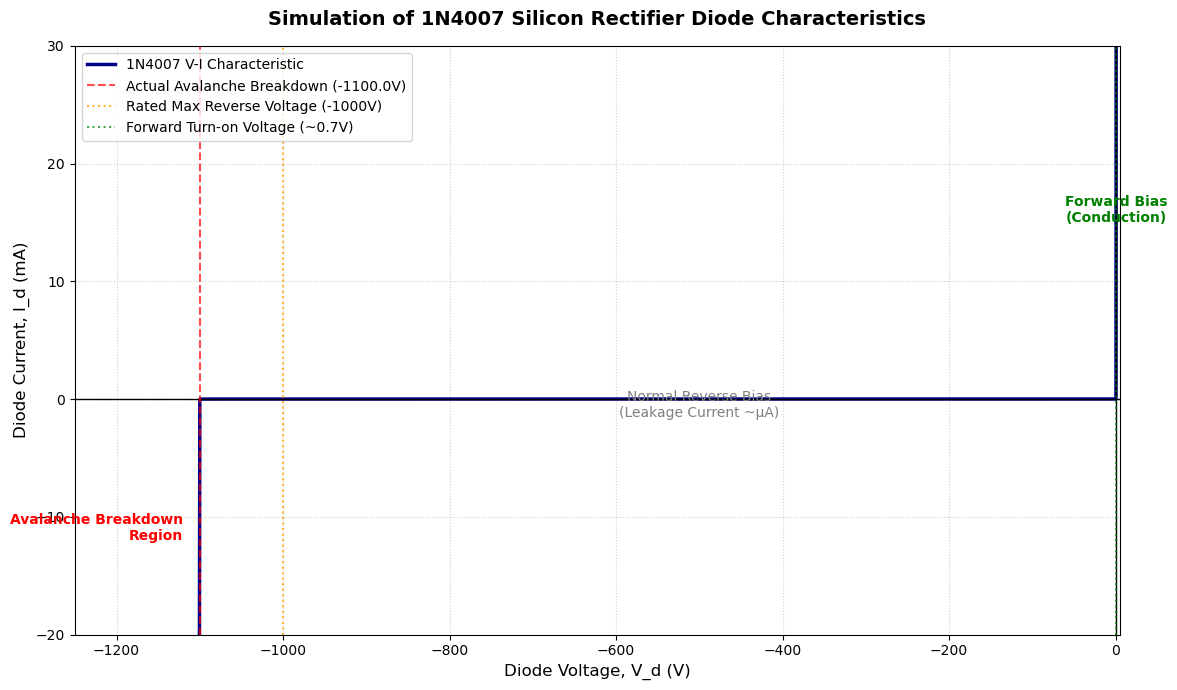

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. 1N4007 SPICE 모델 기반 물리 상수 및 소자 파라미터 설정
# =========================================================================
I_s = 14.11e-9  # SPICE 파라미터 기반 포화 전류 (Saturation Current)  I_s=14.11nA
n = 1.98                   # 배율 인자 (Ideality Factor)
V_t = 0.026                # 열 전압 (Thermal Voltage @ 300K): 26mV

# 1N4007 특유의 고전압 항복 파라미터
V_br = -1100.0             # 실제 애벌런치 항복 개시 전압 (데이터시트 정격은 1000V)
M_n = 3                    # 밀러 지수 (항복 곡선의 기울기 무릎 조절)

# =========================================================================
# 2. 1N4007 통합 전류(I_d) 계산 함수
# =========================================================================
def calculate_1n4007_current(V_d):
    """
    1N4007 규격을 추종하는 순방향 지수 특성 및 역방향 고전압 항복 전류 모델
    """
    # 1) 순방향 및 일반 역방향 (Shockley 방정식)
    I_shockley = I_s * (np.exp(V_d / (n * V_t)) - 1)
    
    # 2) 역방향 고전압 항복 구간 연산
    if V_d < 0:
        ratio = np.abs(V_d / V_br)
        if ratio >= 1.0:
            # 항복 전압 초과 시 급격한 전류 증가 (실제 회로에선 보호 저항이 없으면 소자 파괴)
            # 여기서는 전류 제한 범위(-1.5A)까지만 시뮬레이션 시각화 처리
            I_breakdown = -0.05 * (np.abs(V_d) - np.abs(V_br)) - 5e-6
            return I_breakdown
        else:
            # 애벌런치 증배 공식 적용
            M = 1 / (1 - (ratio ** M_n))
            return I_shockley * M
            
    return I_shockley

# 넘파이 배열 연산을 위해 벡터화 적용
simulate_1n4007 = np.vectorize(calculate_1n4007_current)

# =========================================================================
# 3. 전압 데이터 생성 (항복점 영역과 순방향 영역을 포함하도록 조절)
# =========================================================================
# -1200V부터 +1.5V까지 정밀한 8000개 구간으로 분할 스윕
V_range = np.linspace(-1200.0, 1.5, 8000)
I_range = simulate_1n4007(V_range)

# =========================================================================
# 4. 결과 시각화 (Matplotlib 그래프 플로팅)
# =========================================================================
fig, ax = plt.subplots(figsize=(12, 7))

# 1N4007 V-I 특성 곡선 플롯 (전류 단위를 mA로 변환하여 가시성 확보)
ax.plot(V_range, I_range * 1000, color='darkblue', linewidth=2.5, label='1N4007 V-I Characteristic')

# 기준축(X축 0V, Y축 0mA) 강조 표시
ax.axhline(0, color='black', linewidth=1.0)
ax.axvline(0, color='black', linewidth=1.0)

# 1N4007 주요 스펙 포인트 가이드라인 표시
ax.axvline(V_br, color='red', linestyle='--', alpha=0.7, label=f'Actual Avalanche Breakdown ({V_br}V)')
ax.axvline(-1000.0, color='orange', linestyle=':', alpha=0.8, label='Rated Max Reverse Voltage (-1000V)')
ax.axvline(0.7, color='green', linestyle=':', alpha=0.7, label='Forward Turn-on Voltage (~0.7V)')

# 그래프 타이틀 및 세부 축 텍스트 레이아웃 설정
ax.set_title('Simulation of 1N4007 Silicon Rectifier Diode Characteristics', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Diode Voltage, V_d (V)', fontsize=12)
ax.set_ylabel('Diode Current, I_d (mA)', fontsize=12)

# 가독성을 위한 축 출력 범위 고정 (항복 영역의 무한대 발산 왜곡 방지)
ax.set_ylim(-20, 30)
ax.set_xlim(-1250, 5)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=10)

# 영역별 주석 추가
ax.text(1.2, 15, 'Forward Bias\n(Conduction)', color='green', fontsize=10, fontweight='bold', ha='center')
ax.text(-500, -1.5, 'Normal Reverse Bias\n(Leakage Current ~μA)', color='gray', fontsize=10, ha='center')
ax.text(V_br - 20, -12, 'Avalanche Breakdown\nRegion', color='red', fontsize=10, fontweight='bold', ha='right')

plt.tight_layout()
plt.show()